In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load final dataset
df = pd.read_csv('../data/resume_data_final.csv')

print(f"Dataset shape: {df.shape}")
print(f"Fit rate: {df['fit_label'].mean()*100:.1f}%")
print("Loaded successfully!")

Dataset shape: (9320, 47)
Fit rate: 49.0%
Loaded successfully!


In [2]:
# Updated feature columns - now 8 features
feature_cols = [
    'domain_alignment_v2',
    'skill_overlap_count',
    'skill_overlap_pct',
    'full_text_semantic_sim',
    'skills_semantic_sim',
    'has_certification',
    'education_match',
    'experience_match'
]

# Target using original matched_score with 0.70 threshold
df['fit_label_original'] = (df['matched_score'] >= 0.70).astype(int)

X = df[feature_cols]
y = df['fit_label_original']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train fit rate: {y_train.mean()*100:.1f}%")
print(f"Test fit rate: {y_test.mean()*100:.1f}%")

Training set: (7456, 8)
Test set: (1864, 8)
Train fit rate: 46.9%
Test fit rate: 46.9%


In [5]:
# Scale features - Logistic Regression works better with scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Fit', 'Fit']))

Training Logistic Regression...

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  69.7%
ROC-AUC:   0.716

Classification Report:
              precision    recall  f1-score   support

     Not Fit       0.54      0.24      0.33       586
         Fit       0.72      0.91      0.80      1278

    accuracy                           0.70      1864
   macro avg       0.63      0.57      0.57      1864
weighted avg       0.67      0.70      0.66      1864



In [9]:
# Rescale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train both versions
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model_balanced.fit(X_train_scaled, y_train)

# Evaluate both
for name, model in [('Unbalanced', lr_model), ('Balanced', lr_model_balanced)]:
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    print(f"\n=== LOGISTIC REGRESSION ({name}) ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
    print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}")
    print(classification_report(y_test, y_pred, target_names=['Not Fit', 'Fit']))


=== LOGISTIC REGRESSION (Unbalanced) ===
Accuracy: 65.3%
ROC-AUC:  0.711
              precision    recall  f1-score   support

     Not Fit       0.65      0.75      0.70       990
         Fit       0.66      0.55      0.60       874

    accuracy                           0.65      1864
   macro avg       0.65      0.65      0.65      1864
weighted avg       0.65      0.65      0.65      1864


=== LOGISTIC REGRESSION (Balanced) ===
Accuracy: 65.7%
ROC-AUC:  0.711
              precision    recall  f1-score   support

     Not Fit       0.67      0.70      0.69       990
         Fit       0.64      0.60      0.62       874

    accuracy                           0.66      1864
   macro avg       0.66      0.65      0.65      1864
weighted avg       0.66      0.66      0.66      1864



In [7]:
# Check different thresholds for fit_label
thresholds = [0.65, 0.70, 0.75, 0.80]
for t in thresholds:
    label = (df['matched_score'] >= t).astype(int)
    rate = label.mean() * 100
    print(f"Threshold {t}: fit rate = {rate:.1f}%")


Threshold 0.65: fit rate = 68.6%
Threshold 0.7: fit rate = 46.9%
Threshold 0.75: fit rate = 38.4%
Threshold 0.8: fit rate = 24.0%


In [10]:
# Stage 2 - Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)  # no scaling needed for Random Forest

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Not Fit', 'Fit']))

Training Random Forest...

=== RANDOM FOREST RESULTS ===
Accuracy: 65.8%
ROC-AUC:  0.706

              precision    recall  f1-score   support

     Not Fit       0.68      0.67      0.67       990
         Fit       0.63      0.65      0.64       874

    accuracy                           0.66      1864
   macro avg       0.66      0.66      0.66      1864
weighted avg       0.66      0.66      0.66      1864



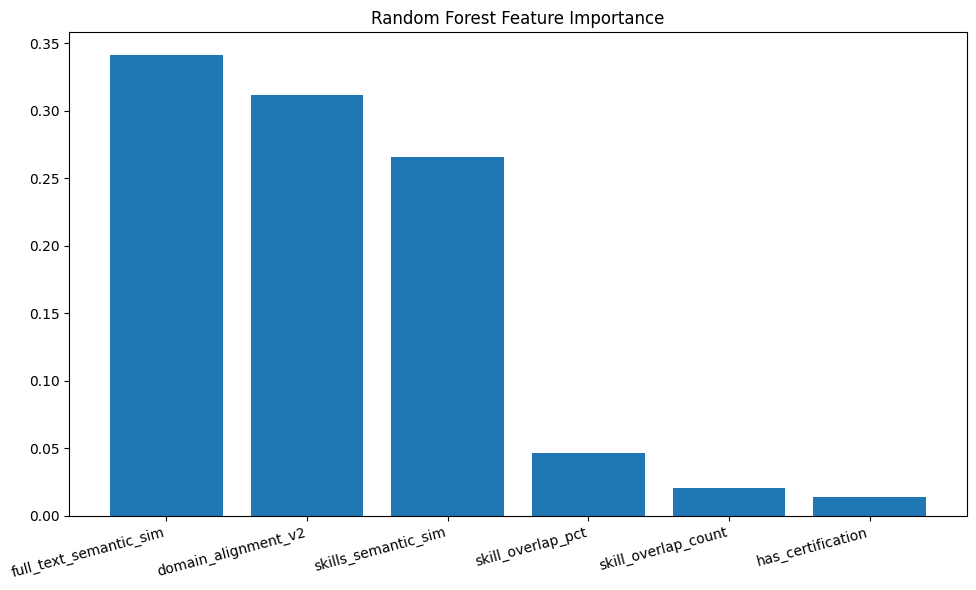

Feature importance ranking:
  full_text_semantic_sim: 0.341
  domain_alignment_v2: 0.311
  skills_semantic_sim: 0.266
  skill_overlap_pct: 0.047
  skill_overlap_count: 0.021
  has_certification: 0.014


In [11]:
# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), 
           [feature_cols[i] for i in indices], 
           rotation=15, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for i in indices:
    print(f"  {feature_cols[i]}: {importances[i]:.3f}")

In [13]:
import joblib

# Save models and scaler
joblib.dump(lr_model_balanced, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Models saved!")

# Save model comparison summary
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [65.7, 65.8],
    'ROC_AUC': [0.711, 0.706],
    'Not_Fit_F1': [0.69, 0.67],
    'Fit_F1': [0.62, 0.64]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))
results_df.to_csv('../models/model_comparison.csv', index=False)

Models saved!

Model Comparison:
              Model  Accuracy  ROC_AUC  Not_Fit_F1  Fit_F1
Logistic Regression      65.7    0.711        0.69    0.62
      Random Forest      65.8    0.706        0.67    0.64


Computing SHAP values...
Generating SHAP summary plot...


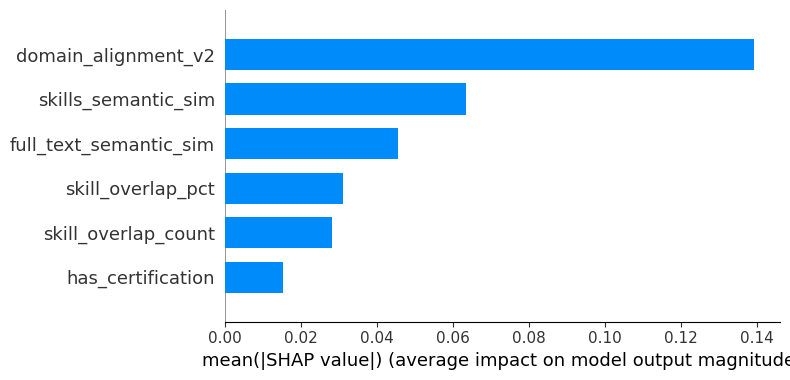

In [14]:
import shap

# Create SHAP explainer using Random Forest
print("Computing SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot - shows which features matter most overall
print("Generating SHAP summary plot...")
shap.summary_plot(
    shap_values[:, :, 1],  # class 1 = Fit
    X_test,
    feature_names=feature_cols,
    plot_type='bar',
    show=True
)

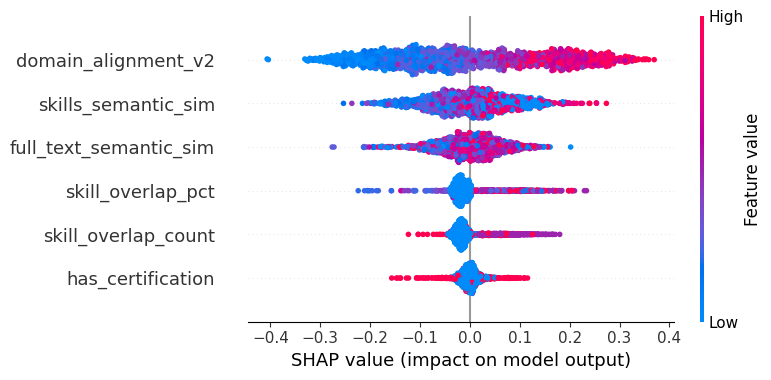

In [15]:
# Detailed SHAP dot plot
shap.summary_plot(
    shap_values[:, :, 1],  # class 1 = Fit
    X_test,
    feature_names=feature_cols
)

In [16]:
# Save SHAP explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer saved!")

SHAP explainer saved!


In [3]:
print("Current feature columns:", X_train.columns.tolist())
print("Number of features:", X_train.shape[1])
print("Train fit rate:", y_train.mean())

Current feature columns: ['domain_alignment_v2', 'skill_overlap_count', 'skill_overlap_pct', 'full_text_semantic_sim', 'skills_semantic_sim', 'has_certification', 'education_match', 'experience_match']
Number of features: 8
Train fit rate: 0.46901824034334766


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("=== LOGISTIC REGRESSION ===")
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.3f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Fit', 'Fit']))

print("\n=== RANDOM FOREST ===")
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.3f}")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fit', 'Fit']))

=== LOGISTIC REGRESSION ===
Accuracy: 68.3%
ROC-AUC:  0.737
              precision    recall  f1-score   support

     Not Fit       0.70      0.70      0.70       990
         Fit       0.66      0.67      0.66       874

    accuracy                           0.68      1864
   macro avg       0.68      0.68      0.68      1864
weighted avg       0.68      0.68      0.68      1864


=== RANDOM FOREST ===
Accuracy: 69.1%
ROC-AUC:  0.754
              precision    recall  f1-score   support

     Not Fit       0.71      0.70      0.71       990
         Fit       0.67      0.69      0.68       874

    accuracy                           0.69      1864
   macro avg       0.69      0.69      0.69      1864
weighted avg       0.69      0.69      0.69      1864



In [5]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature importance ranking:")
for i in indices:
    print(f"  {feature_cols[i]}: {importances[i]:.3f}")

Feature importance ranking:
  domain_alignment_v2: 0.306
  full_text_semantic_sim: 0.296
  skills_semantic_sim: 0.238
  skill_overlap_pct: 0.044
  education_match: 0.043
  experience_match: 0.039
  skill_overlap_count: 0.019
  has_certification: 0.015


In [6]:
import joblib

joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Updated models saved!")

# Update SHAP explainer for new model
import shap
explainer = shap.TreeExplainer(rf_model)
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer updated!")

Updated models saved!
SHAP explainer updated!
